## Business Goal

Segment credit card customers by income, gender, and credit limit to:
- identify high-value customers for upsell or premium products
- detect under-served segments (low limit but high income)
- tailor marketing and credit line strategies by segment


In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 6)

## Load & Inspect Data

In [22]:
df=pd.read_csv("credit.csv")

In [23]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [24]:
print("Shape:", df.shape)
print(df.head())

Shape: (10127, 23)
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0                  777          

In [25]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category     

In [50]:
print("\nAny nulls by column:")
print(df.isnull().any())



Any nulls by column:
CLIENTNUM                                                                                                                             False
Attrition_Flag                                                                                                                        False
Customer_Age                                                                                                                          False
Gender                                                                                                                                False
Dependent_count                                                                                                                       False
Education_Level                                                                                                                       False
Marital_Status                                                                                                                        Fals

## Basic Cleaning & Encoding

In [28]:
### Strip whitespace from key categorical fields

df['Income_Category'] = df['Income_Category'].str.strip()
df['Gender'] = df['Gender'].str.strip()


In [9]:
### # Ordinal mappings
Gender_map = {'M': 2, 'F': 1}
Income_map = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5,
    'Unknown': 6
}

In [30]:
df['Gender_ordinal'] = df.Gender.map(Gender_map)
df.head(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2,Income_ordinal,Gender_ordinal
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991,3,2
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994,1,1
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998,4,2
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987,1,1
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998,3,2
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.99994,2,2
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.99988,5,2
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.99991,3,2
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,19835.0,3.355,1350,24,1.182,0.113,0.000045,0.99996,3,2
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,9979.0,1.524,1441,32,0.882,0.144,0.000303,0.99970,4,2


In [49]:
df['Income_ordinal'] = df['Income_Category'].map(Income_map)
df.head(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2,Income_ordinal,Gender_ordinal,Credit_card_segments_num,Credit_card_segments
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1144,42,1.625,0.061,0.000093,0.99991,3,2,4,Cluster 5
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1291,33,3.714,0.105,0.000057,0.99994,1,1,0,Cluster 1
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1887,20,2.333,0.000,0.000021,0.99998,4,2,4,Cluster 5
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1171,20,2.333,0.760,0.000134,0.99987,1,1,0,Cluster 1
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,816,28,2.500,0.000,0.000022,0.99998,3,2,1,Cluster 2
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,1088,24,0.846,0.311,0.000055,0.99994,2,2,1,Cluster 2
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,1330,31,0.722,0.066,0.000123,0.99988,5,2,3,Cluster 4
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,1538,36,0.714,0.048,0.000086,0.99991,3,2,3,Cluster 4
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,1350,24,1.182,0.113,0.000045,0.99996,3,2,3,Cluster 4
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,1441,32,0.882,0.144,0.000303,0.99970,4,2,4,Cluster 5


In [33]:
### Drop rows with missing key fields used for clustering

df = df.dropna(subset=['Income_ordinal', 'Gender_ordinal', 'Credit_Limit'])
print("\nShape after dropping missing key fields:", df.shape)


Shape after dropping missing key fields: (10127, 25)


## Feature Selection & Scaling

In [13]:
clustering_data = df[['Gender_ordinal', 'Income_ordinal', 'Credit_Limit']].copy()

In [14]:
scaler = MinMaxScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

## K-Means Clustering

In [39]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(clustering_data_scaled)

df['Credit_card_segments_num'] = clusters
df['Credit_card_segments'] = df['Credit_card_segments_num'].map({
    0: 'Cluster 1',
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4',
    4: 'Cluster 5'
})


## Segment Profiles (Business KPIs)

In [41]:
segment_profile = (
    df
    .groupby('Credit_card_segments')
    .agg(
        customers=('Credit_card_segments', 'size'),
        avg_income_band=('Income_ordinal', 'mean'),
        avg_credit_limit=('Credit_Limit', 'mean'),
        avg_gender_code=('Gender_ordinal', 'mean')
    )
    .sort_values('avg_credit_limit', ascending=False)
)
print("\nSegment profile (sorted by avg_credit_limit):")
print(segment_profile)


Segment profile (sorted by avg_credit_limit):
                      customers  avg_income_band  avg_credit_limit  \
Credit_card_segments                                                 
Cluster 4                  1147         4.097646      29315.891892   
Cluster 5                  1666         4.126050       9670.071669   
Cluster 3                  1060         6.000000       9373.363585   
Cluster 2                  1956         2.325153       5502.206800   
Cluster 1                  4298         1.235924       3951.150721   

                      avg_gender_code  
Credit_card_segments                   
Cluster 4                         2.0  
Cluster 5                         2.0  
Cluster 3                         1.0  
Cluster 2                         2.0  
Cluster 1                         1.0  


In [42]:
### Overall reference for credit limit
overall_avg_limit = df["Credit_Limit"].mean()
print("\nOverall average credit limit:", round(overall_avg_limit, 2))


Overall average credit limit: 8631.95


In [43]:
# Define high-value and under-served segments for business story
high_value_segments = segment_profile[
    segment_profile["avg_credit_limit"] > overall_avg_limit
]

under_served_segments = segment_profile[
    (segment_profile["avg_income_band"] >= 4)  # high income
    & (segment_profile["avg_credit_limit"] < overall_avg_limit)
]

print("\nHigh-value segments (above overall avg limit):")
print(high_value_segments)

print("\nUnder-served segments (high income, below avg limit):")
print(under_served_segments)



High-value segments (above overall avg limit):
                      customers  avg_income_band  avg_credit_limit  \
Credit_card_segments                                                 
Cluster 4                  1147         4.097646      29315.891892   
Cluster 5                  1666         4.126050       9670.071669   
Cluster 3                  1060         6.000000       9373.363585   

                      avg_gender_code  
Credit_card_segments                   
Cluster 4                         2.0  
Cluster 5                         2.0  
Cluster 3                         1.0  

Under-served segments (high income, below avg limit):
Empty DataFrame
Columns: [customers, avg_income_band, avg_credit_limit, avg_gender_code]
Index: []


## Visualisations

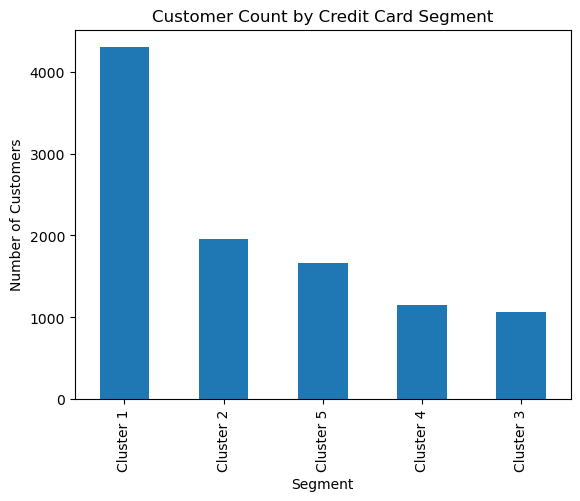

In [18]:
df['Credit_card_segments'].value_counts().plot(kind='bar')
plt.title('Customer Count by Credit Card Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()


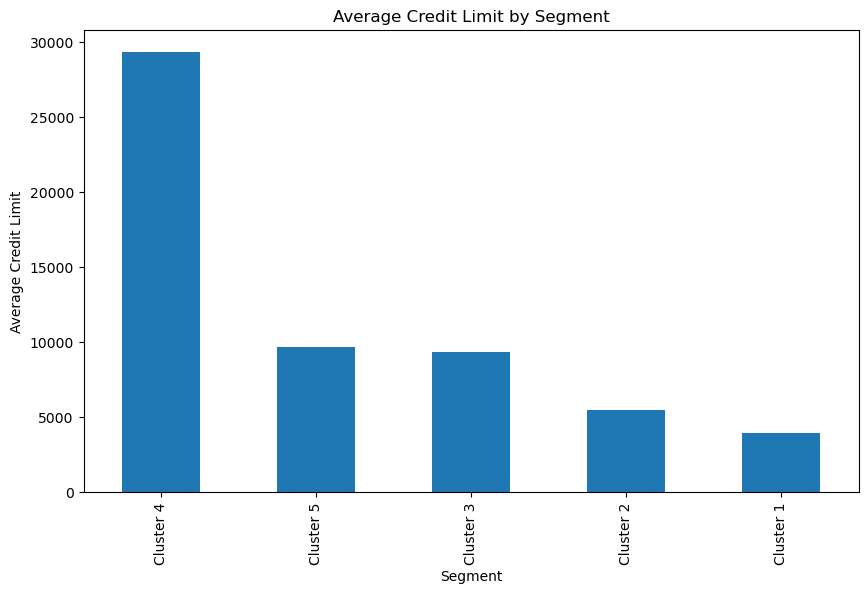

In [45]:
### Average credit limit by segment
segment_profile["avg_credit_limit"].plot(kind="bar")
plt.title("Average Credit Limit by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Credit Limit")
plt.show()

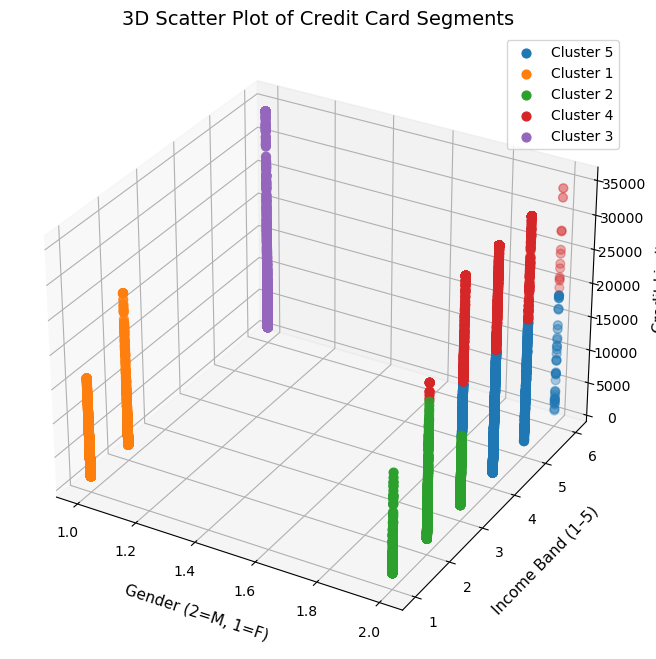

In [46]:
### 3D scatter plot (Gender, Income, Credit Limit)
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for segment in df["Credit_card_segments"].unique():
    seg_data = df[df["Credit_card_segments"] == segment]
    ax.scatter(
        seg_data["Gender_ordinal"],
        seg_data["Income_ordinal"],
        seg_data["Credit_Limit"],
        s=40,
        label=str(segment),
    )

ax.set_xlabel("Gender (2=M, 1=F)", fontsize=11, labelpad=10)
ax.set_ylabel("Income Band (1–5)", fontsize=11, labelpad=10)
ax.set_zlabel("Credit Limit", fontsize=11, labelpad=10)
ax.set_title("3D Scatter Plot of Credit Card Segments", fontsize=14)
ax.legend()
plt.show()

## Business Summary

In [47]:
total_customers = len(df)
max_limit_seg = segment_profile["avg_credit_limit"].idxmax()
min_limit_seg = segment_profile["avg_credit_limit"].idxmin()

print("\n=== Business Summary ===")
print(f"Total customers segmented: {total_customers}")
print(f"Highest-limit segment: {max_limit_seg} "
      f"(avg limit = ${segment_profile.loc[max_limit_seg, 'avg_credit_limit']:.0f})")
print(f"Lowest-limit segment: {min_limit_seg} "
      f"(avg limit = ${segment_profile.loc[min_limit_seg, 'avg_credit_limit']:.0f})")

if not under_served_segments.empty:
    print("\nUnder-served opportunity: high-income segments with below-average limits:")
    print(under_served_segments[["customers", "avg_income_band", "avg_credit_limit"]])
else:
    print("\nNo clear under-served high-income segments detected based on current rules.")


=== Business Summary ===
Total customers segmented: 10127
Highest-limit segment: Cluster 4 (avg limit = $29316)
Lowest-limit segment: Cluster 1 (avg limit = $3951)

No clear under-served high-income segments detected based on current rules.
